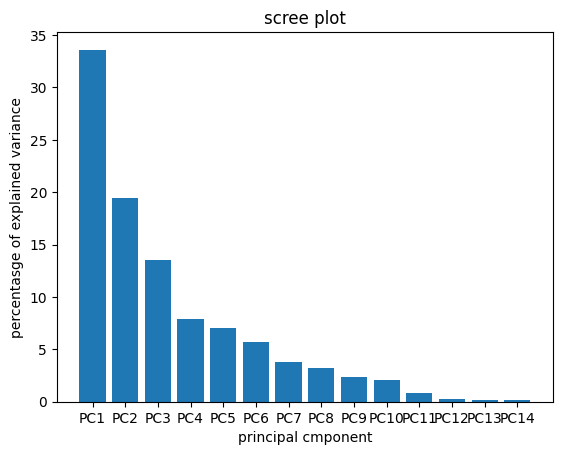

MaxTemp          0.413369
Temp9am          0.412768
Temp3pm          0.404120
MinTemp          0.358795
Pressure3pm     -0.289294
Humidity9am     -0.286078
Pressure9am     -0.264115
Humidity3pm     -0.215925
WindGustSpeed    0.163300
WindSpeed3pm     0.137248
dtype: float64


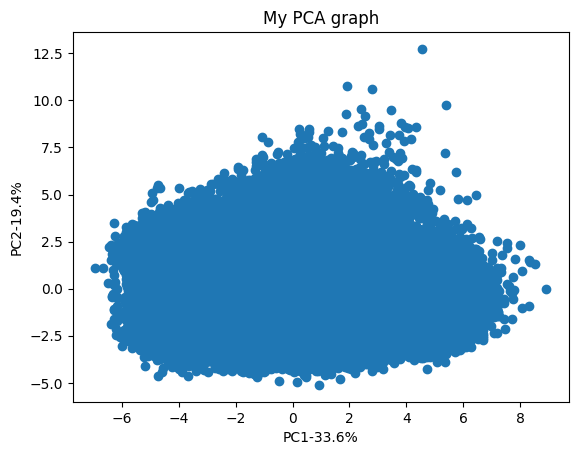

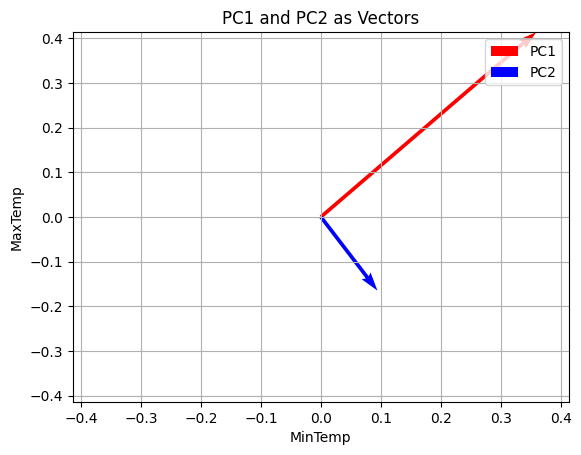

In [ ]:
import pandas as pd
import numpy as np
import random as rd
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt

path=r'C:\Users\samik\Downloads\weatherAUS (3).zip'
data= pd.read_csv(path)
data = data.drop(columns=['Date','Location','Evaporation','Sunshine','WindGustDir','WindDir9am','WindDir3pm','RainToday','RainTomorrow'])
column_mean= data['Rainfall'].replace(0, pd.NA).mean()
data['Rainfall']=data['Rainfall'].replace(0,column_mean)
data = data.fillna(data.mean())
scaled_data=preprocessing.scale(data)  #to standardize or normalize the data. It centers the data and scales it to have a mean of 0 and a standard deviation of 1 for each feature (column).


# Now you can apply PCA
pca = PCA()#an instance of the PCA (Principal Component Analysis) class from sklearn.decomposition, and it specifies the dimensionality of your data you want to reduce it to.

#pca=PCA()#PCA object
pca.fit(scaled_data)#all the PCA math - calculate loading scores and the variation 
pca_data = pca.transform(scaled_data)#is used to transform the standardized data (scaled_data) into the new principal component space after fitting the PCA model.

per_var = np.round(pca.explained_variance_ratio_*100,decimals=1)#calculating the % of variation an PC accounts for
labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

plt.bar(x=range(1,len(per_var)+1),height=per_var,tick_label=labels)
plt.ylabel('percentasge of explained variance')
plt.xlabel('principal cmponent')
plt.title('scree plot')
plt.show()

pca_df = pd.DataFrame(pca_data, index=data.index, columns=labels)


plt.scatter(pca_df.PC1,pca_df.PC2)
plt.title('My PCA graph')
plt.xlabel('PC1-{0}%'.format(per_var[0]))
plt.ylabel('PC2-{0}%'.format(per_var[1]))



loading_scores= pd.Series(pca.components_[0],index=data.columns)
sorted_loading_scores= loading_scores.abs().sort_values(ascending=False)
top_10_data=sorted_loading_scores[0:10].index.values
print(loading_scores[top_10_data])



# Get the loadings for PC1 and PC2 (first two components)
pc1 = pca.components_[0]  # PC1
pc2 = pca.components_[1]  # PC2

# Select the first two features (or any two features) for the 2D plot
feature1 = data.columns[0]  # Feature 1 
feature2 = data.columns[1]  # Feature 2 

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the vectors for PC1 and PC2 as arrows starting from the origin
ax.quiver(0, 0, pc1[0], pc1[1], angles='xy', scale_units='xy', scale=1, color='r', label='PC1')
ax.quiver(0, 0, pc2[0], pc2[1], angles='xy', scale_units='xy', scale=1, color='b', label='PC2')

# Set the limits for better visibility (based on the max values of PC1 and PC2)
max_val = np.max([np.abs(pc1).max(), np.abs(pc2).max()])
ax.set_xlim([-max_val, max_val])
ax.set_ylim([-max_val, max_val])

# Adding labels and legend
ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_title('PC1 and PC2 as Vectors')
ax.legend()

# Display the plot
plt.grid(True)
plt.show()


